#0. Exploracion preliminar

##Separacion de datos

In [66]:
import requests
url ='https://raw.githubusercontent.com/JuanMoreno003/txt/refs/heads/main/Conagua.txt'
response = requests.get(url)
contenido = response.text

In [67]:
import pandas as pd
data = pd.read_csv(url,encoding='latin1')
data

,COMISIÃN NACIONAL DEL AGUA
0,COORDINACIÃN GENERAL DEL SERVICIO METEOROLÃG...
1,BASE DE DATOS CLIMATOLÃGICA NACIONAL
2,REGISTRO DIARIO HISTÃRICO
3,EMISIÃN : 01/05/2026
4,DATOS DISPONIBLES EN LA BASE DE DATOS A: MAY D...
...,...
23809,2026-03-27\t0\t6.26\t34\t23
23810,2026-03-28\t0\t4.62\t35\t22
23811,2026-03-29\t0\t4.15\t34\t23
23812,2026-03-30\t0\t7.2\t36\t21.5


In [68]:
import pandas as pd
data = pd.read_csv(url, nrows=2,encoding='latin1')
data

,COMISIÃN NACIONAL DEL AGUA
0,COORDINACIÃN GENERAL DEL SERVICIO METEOROLÃG...
1,BASE DE DATOS CLIMATOLÃGICA NACIONAL


In [69]:
import pandas as pd
data = pd.read_csv(url, skiprows=3 ,nrows=13, header=None,encoding='latin1')
data

,0
0,REGISTRO DIARIO HISTÃRICO
1,EMISIÃN : 01/05/2026
2,DATOS DISPONIBLES EN LA BASE DE DATOS A: MAY D...
3,CON LA INFORMACIÃN SUMINISTRADA POR LAS UNIDA...
4,ESTACIÃN : 25015
5,NOMBRE : CULIACAN (DGE)
6,ESTADO : SINALOA
7,MUNICIPIO : CULIACÃN
8,SITUACIÃN : OPERANDO
9,CVE-OMM :


In [70]:
from numpy import array
import pandas as pd
c = pd.read_csv(url, skiprows=22,sep='\s+', nrows=1,encoding='latin1')
columns = [' '+c]
col =array(columns)
col

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1315/735255427.py:3: SyntaxWarning: invalid escape sequence '\s'
  c = pd.read_csv(url, skiprows=22,sep='\s+', nrows=1,encoding='latin1')


array([[[' (mm)', ' (mm)', ' (Â°C', ' )', ' (Â°C)']]], dtype=object)

# Data Understanding

##Datos

Lo primero que podemos analizar a simple vista es:
* ¿Qué representa cada columna?

FECHA → tiempo

PRECIP → precipitación

EVAP → evaporación

TMAX, TMIN → temperaturas

*  Frecuencia de toma de datos

Diaria

* ¿Problemas visibles?

'Nan' en vez de "Nulo"

encoding raro (�)

encabezados desalineados

# Data Ingesting

###Extraccion tabla principal

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

lines = contenido.splitlines()
for i, line in enumerate(lines):
    if "FECHA" in line and "PRECIP" in line:
        header_idx = i
        break


columns = ['FECHA', 'PRECIP', 'EVAP', 'TMAX', 'TMIN']

data = pd.read_csv(StringIO(contenido),
                   skiprows=header_idx + 2,
                   sep=r'\s+',
                   names=columns,
                   na_values=['Nulo'])

data['FECHA'] = pd.to_datetime(data['FECHA'])
cols_numericas = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
for col in cols_numericas:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,1961-01-01,0.0,2.9,22.0,10.5
1,1961-01-02,0.0,2.7,25.0,9.0
2,1961-01-03,0.0,3.7,29.0,10.0
3,1961-01-04,0.0,2.5,22.0,13.0
4,1961-01-05,0.0,1.1,24.0,14.0


# Analisis exploratorio (EDA)

In [72]:
data.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,1961-01-01,0.0,2.9,22.0,10.5
1,1961-01-02,0.0,2.7,25.0,9.0
2,1961-01-03,0.0,3.7,29.0,10.0
3,1961-01-04,0.0,2.5,22.0,13.0
4,1961-01-05,0.0,1.1,24.0,14.0


In [73]:
data.tail()

,FECHA,PRECIP,EVAP,TMAX,TMIN
23792,2026-03-27,0.0,6.26,34.0,23.0
23793,2026-03-28,0.0,4.62,35.0,22.0
23794,2026-03-29,0.0,4.15,34.0,23.0
23795,2026-03-30,0.0,7.20,36.0,21.5
23796,2026-03-31,0.0,NaN,36.0,22.0


In [74]:
data.describe()

,FECHA,PRECIP,EVAP,TMAX,TMIN
count,23797,23760.000000,22454.000000,23700.000000,23700.000000
mean,1993-08-13 14:10:29.625582976,1.855900,5.674334,32.778557,17.957485
min,1961-01-01 00:00:00,0.000000,0.010000,14.000000,2.000000
25%,1977-04-16 00:00:00,0.000000,3.800000,30.000000,13.000000
50%,1993-07-30 00:00:00,0.000000,5.450000,33.000000,18.000000
75%,2009-12-14 00:00:00,0.000000,7.500000,36.000000,23.000000
max,2026-03-31 00:00:00,258.000000,19.250000,46.000000,30.500000
std,NaN,8.506479,2.507133,4.095137,5.700840


In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23797 entries, 0 to 23796
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   23797 non-null  datetime64[ns]
 1   PRECIP  23760 non-null  float64       
 2   EVAP    22454 non-null  float64       
 3   TMAX    23700 non-null  float64       
 4   TMIN    23700 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 929.7 KB


In [76]:
data.isnull().sum()

,0
FECHA,0
PRECIP,37
EVAP,1343
TMAX,97
TMIN,97


In [77]:
for column in ['PRECIP', 'EVAP', 'TMAX', 'TMIN']:
    if column in data.columns:
        mean_value = data[column].mean()
        data[column] = data[column].fillna(mean_value)

# Display the count of null values after filling
print(data.isnull().sum())

FECHA     0
PRECIP    0
EVAP      0
TMAX      0
TMIN      0
dtype: int64


#1. Análisis estadístico descriptivo


In [81]:
data.set_index('FECHA', inplace=True)

Datos de la columna PRECIP

  Media: 1.8558998316498316
  Mediana: 0.0
  Moda: 0.0
  Rango: 258.0
  Varianza: 72.24768120532556
  Desviacion estandar: 8.499863599218846
Datos de la columna EVAP

  Media: 5.674334194352899
  Mediana: 5.674334194352899
  Moda: 5.674334194352899
  Rango: 19.24
  Varianza: 5.9309636912172605
  Desviacion estandar: 2.4353569946143954
Datos de la columna TMAX

  Media: 32.77855696202531
  Mediana: 33.0
  Moda: 34.0
  Rango: 32.0
  Varianza: 16.701787806695144
  Desviacion estandar: 4.086782084561782
Datos de la columna TMIN

  Media: 17.95748523206751
  Mediana: 18.0
  Moda: 24.0
  Rango: 28.5
  Varianza: 32.36710212303802
  Desviacion estandar: 5.689209270455607


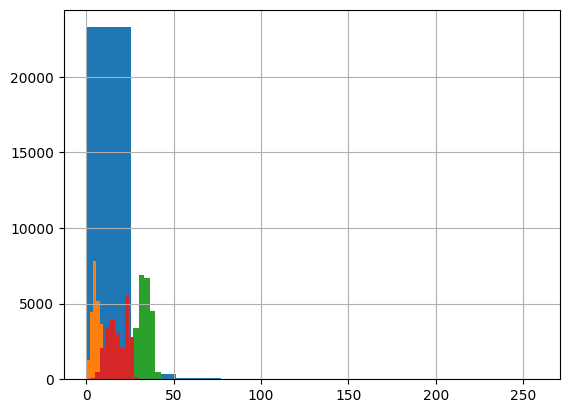

In [82]:

colums=data.columns
for col in colums:
  media = data[col].mean()
  mediana = data[col].median()
  moda = data[col].mode()[0]
  rango = data[col].max() - data[col].min()
  varianza= data[col].var()
  desv_est= data[col].std()

  print(f'====================================\nDatos de la columna {col}')
  data[col].hist()
  print(f"""
  Media: {media}
  Mediana: {mediana}
  Moda: {moda}
  Rango: {rango}
  Varianza: {varianza}
  Desviacion estandar: {desv_est}""")

**Interpretación de los Resultados Estadísticos**


1. ¿Qué nos dice la Desviación Estándar? (La estabilidad del clima)
La desviación estándar nos indica qué tan "inquietos" son los datos. Si es pequeña, los valores son constantes; si es grande, el clima es muy variable.


*   En las Temperaturas (TMAX y TMIN): Los valores son bajos (entre 4 y 5 grados). Esto significa que el clima en Culiacán es predecible. No pasamos de un calor extremo a un frío polar de un día para otro; las temperaturas se mantienen "agrupadas" cerca del promedio.

*   En la Lluvia (PRECIP): Aquí la desviación es muy alta (8.5) comparada con su promedio (1.8). Esto nos indica que la lluvia es errática e inconsistente. La mayor parte del tiempo no llueve, pero cuando ocurre, el cambio es drástico.

2. Comparación de Media y Mediana (El "peso" de los datos)
Al comparar estos dos valores, podemos saber si hay datos extremos que están "jalando" el promedio hacia un lado.



*   El caso de la Lluvia (Sesgo a laderecha):La Mediana es 0.0, lo que significa que en más de la mitad de los días registrados no llovió nada.
Sin embargo, la Media es 1.8. ¿Por qué es más alta? Porque unos pocos días de tormentas muy fuertes actúan como un "peso" que eleva el promedio, aunque no sea lo que ocurre normalmente.
*   El caso de la Temperatura (Simetría): Aquí la Media y la Mediana son casi iguales (aprox. 33°C). Esto indica que el calor en esta región se distribuye de forma equilibrada. Hay tantos días "un poquito más frescos" como días "un poquito más calurosos", sin que un extremo domine al otro.




3. Identificación de Valores Atípicos (Outliers) y su impacto
Los valores atípicos son eventos "extraños" o inusuales que se salen del guion habitual.

* Lluvias Torrenciales: El valor máximo de 258 mm es un claro valor atípico. Es una cantidad inmensa de agua para un solo día (posiblemente un huracán).

* Impacto: Estos valores "engañan" a la estadística. Si solo viéramos la media, pensaríamos que llueve casi 2 mm diarios, cuando la realidad (la moda y mediana) nos dice que lo normal es que esté seco.

* Temperaturas Extremas: Un rango de 32°C en la temperatura máxima indica que ha habido días donde el termómetro bajó drásticamente (quizás un frente frío inusual).

* Impacto: Aunque son raros, estos datos son los más importantes para la planeación civil y agrícola, ya que representan los momentos de riesgo (heladas o canículas).

#Construcción de gráficas

## Histogramas

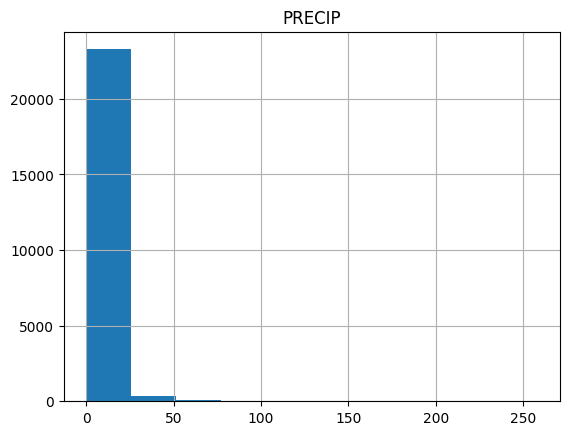

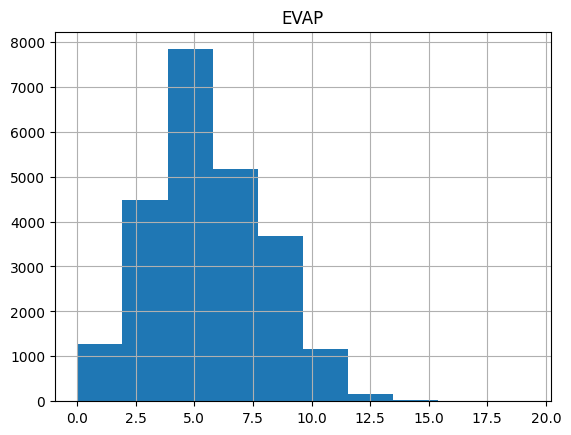

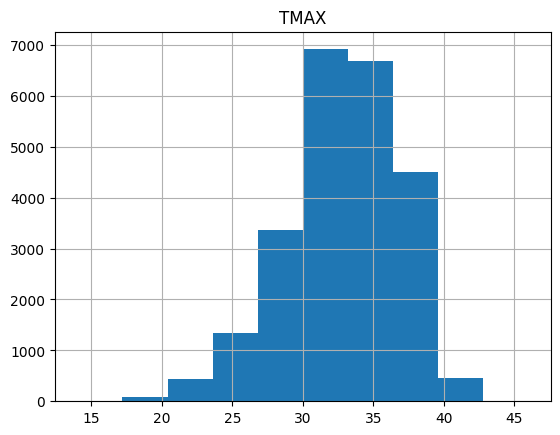

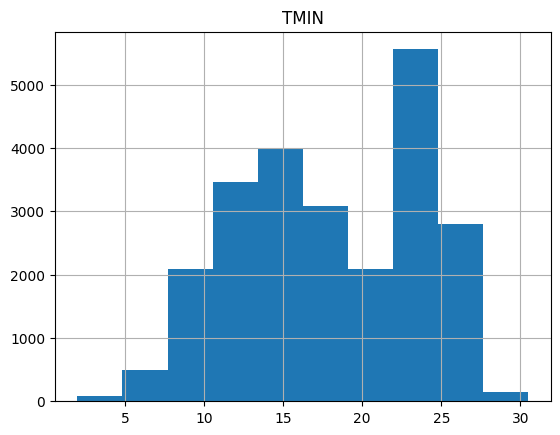

In [83]:
for col in data.columns:
    data.hist(column = col)

Análisis de Histogramas y Formas de Distribución
1. PRECIP (Precipitación)
Forma: Sesgada totalmente a la derecha (positiva).

* Análisis: La gráfica muestra una enorme concentración en la primera barra (cercana al 0). La "cola" de la distribución se extiende largamente hacia la derecha (hasta el valor de 250).

* Relación estadística: Esto confirma por qué la mediana es 0.0 mientras que la media es 1.8. Los pocos eventos de lluvia intensa son invisibles en la altura de las barras finales, pero son los que empujan el promedio hacia arriba.

2. EVAP (Evaporación)
Forma: Simétrica y Unimodal (Campana).

* Análisis: Los datos se agrupan de forma armoniosa alrededor del centro (5-6 mm). La forma es clásica de una distribución normal.

* Relación estadística: Como observamos anteriormente, la media, mediana y moda son casi idénticas (5.67), lo que se refleja visualmente en que el pico más alto del histograma coincide exactamente con el centro de la campana.

3. TMAX (Temperatura Máxima)
Forma: Sesgada a la izquierda (negativa).

* Análisis: La mayor concentración de datos está en el rango de los 30°C a 37°C. La "cola" de la distribución se alarga hacia las temperaturas más bajas (izquierdas).

* Relación estadística: Esto explica por qué la media (32.7) es ligeramente menor que la mediana (33.0) y la moda (34.0). Los días "frescos" son menos frecuentes pero estiran el promedio hacia valores menores.

4. TMIN (Temperatura Mínima)
Forma: Multimodal (específicamente Bimodal).

* Análisis: A diferencia de las otras, esta gráfica presenta dos picos o "jorobas" pronunciadas (una cerca de los 15°C y otra más alta cerca de los 24°C).

* Relación estadística: Esto revela un patrón estacional. El pico en los 15°C representa probablemente el comportamiento del invierno, mientras que el pico en los 24°C representa el verano. La moda de 24.0 destaca el pico más frecuente de las noches calurosas.

##Diagrama de densidad

<Axes: title={'center': 'PRECIP (Precipitación)'}, ylabel='Density'>

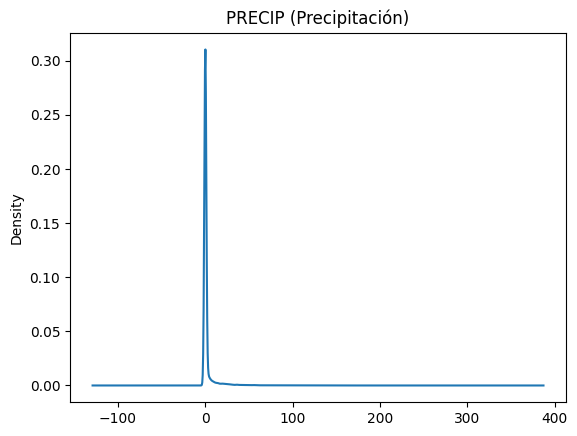

In [96]:
data['PRECIP'].plot.kde(title='PRECIP (Precipitación)')

<Axes: title={'center': 'EVAP (Evaporación)'}, ylabel='Density'>

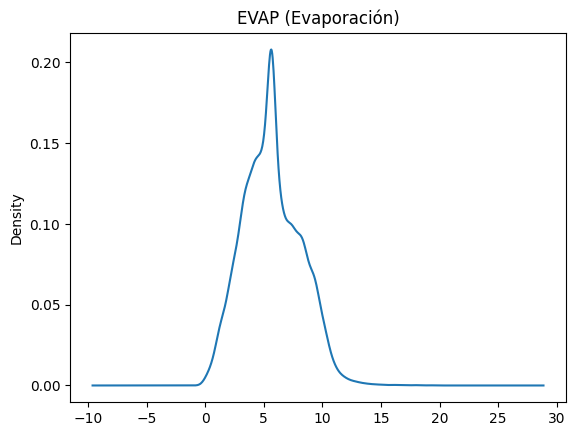

In [97]:
data['EVAP'].plot.kde(title='EVAP (Evaporación)')


<Axes: title={'center': 'TMAX (Temperatura Maxima)'}, ylabel='Density'>

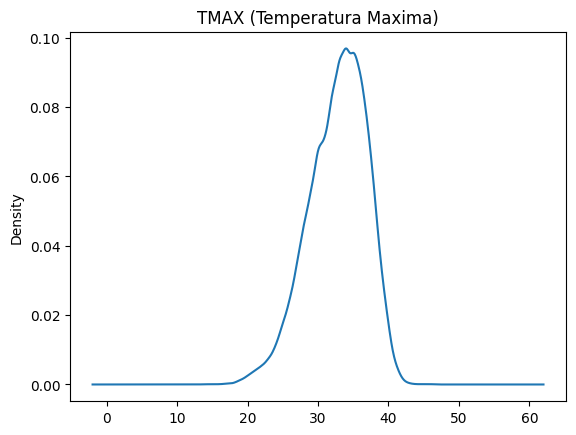

In [98]:
data['TMAX'].plot.kde(title='TMAX (Temperatura Maxima)')

<Axes: title={'center': 'TMIN (Temperatura Minima)'}, ylabel='Density'>

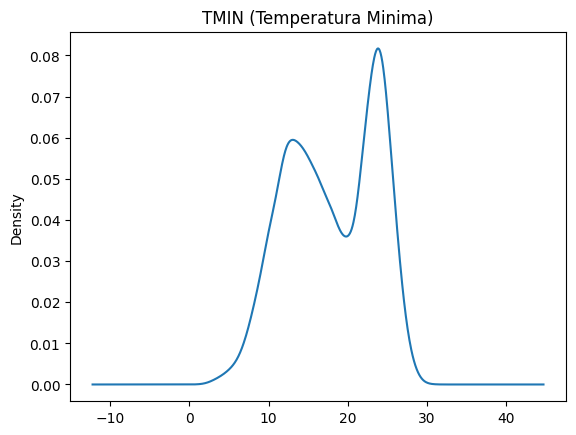

In [99]:
data['TMIN'].plot.kde(title='TMIN (Temperatura Minima)')


Análisis de los Diagramas de Densidad
1. PRECIP (Precipitación)
* Concentración y Dispersión: La gráfica muestra un pico extremadamente agudo y alto en el valor 0. Esto confirma que la probabilidad de un día sin lluvia es máxima. La curva cae casi verticalmente, volviéndose una línea plana muy larga que llega hasta casi los 400.

* Comparación con Histograma: A diferencia del histograma, donde los eventos extremos parecen desaparecer, el diagrama de densidad suaviza la "cola" derecha, permitiéndonos ver que existe una probabilidad (aunque bajísima) de lluvias torrenciales.

2. EVAP (Evaporación)
* Concentración y Dispersión: Presenta una base ancha que va desde el 0 hasta el 12, con su punto más alto cerca del 6. Esto indica una dispersión moderada y constante.

* Comparación con Histograma: Es muy similar al histograma debido a su naturaleza simétrica. Sin embargo, el KDE revela pequeñas "jorobas" o irregularidades en la subida y bajada de la curva que el histograma (por el tamaño de sus barras) oculta, sugiriendo ligeras variaciones en la evaporación diaria.

3. TMAX (Temperatura Máxima)
* Concentración y Dispersión: Los valores se concentran fuertemente entre los 30°C y 38°C. La curva es muy "delgada" en la parte superior, lo que significa que las temperaturas máximas son muy consistentes y no varían demasiado de un día a otro.

* Comparación con Histograma: Aquí es más evidente el sesgo a la izquierda. Mientras el histograma muestra barras descendentes, la densidad muestra una pendiente mucho más suave hacia las temperaturas bajas, confirmando que los días frescos son excepciones graduales en un clima predominantemente caluroso.

4. TMIN (Temperatura Mínima)
* Concentración y Dispersión: Este es el gráfico más interesante visualmente. Confirma la bimodalidad con dos "valles" de concentración claros. Hay un pico de densidad importante en los 24°C (noches cálidas) y otro menor en los 13°C (noches frescas).

* Comparación con Histograma: El diagrama de densidad hace un trabajo mucho mejor que el histograma para separar estas dos "poblaciones" de datos. En el histograma se veían barras altas, pero aquí la curva define claramente que existen dos estados climáticos dominantes en la estación (posiblemente invierno y verano).

##Boxplot (Diagrama de caja y bigotes)

<Axes: >

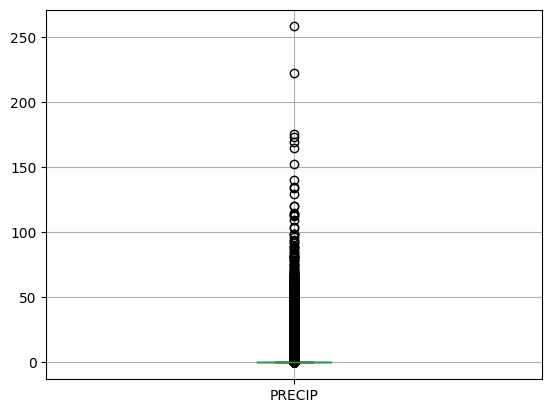

In [92]:
data.boxplot('PRECIP')

<Axes: >

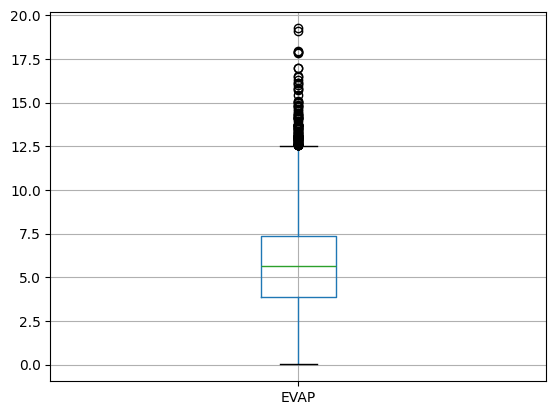

In [93]:
data.boxplot('EVAP')

<Axes: >

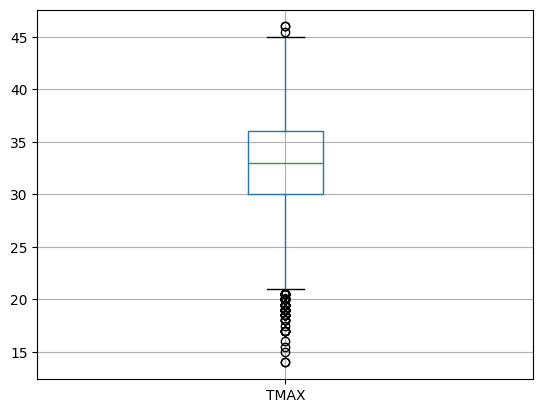

In [94]:
data.boxplot('TMAX')

<Axes: >

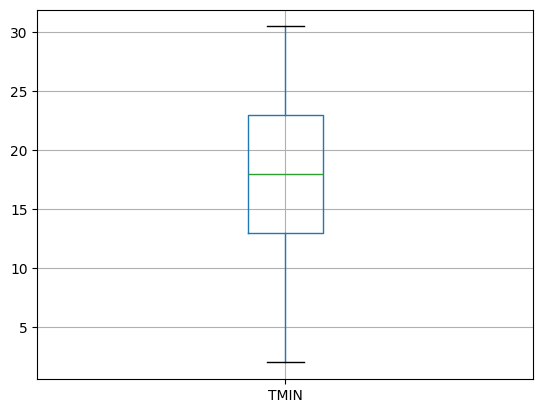

In [95]:
data.boxplot('TMIN')

1. PRECIP (Precipitación)
* Mediana y Cuartiles: La caja está literalmente "aplastada" en el valor 0. Esto indica que tanto el primer cuartil (Q1) como la mediana (Q2) y el tercer cuartil (Q3) son cero o muy cercanos a cero. El Rango Intercuartílico (IQR) es casi inexistente para la mayoría de los días.

* Valores Atípicos (Outliers): Presenta la mayor cantidad de outliers de todo el estudio (los círculos sobre la línea). Estos representan los días de lluvia, destacando valores extremos por encima de 250 mm.

* Sesgo y Dispersión: El sesgo es máximo a la derecha. La dispersión es nula para el 75% de los datos, pero infinita hacia arriba debido a los eventos atípicos.

2. EVAP (Evaporación)
* Mediana y Cuartiles: La mediana se ubica cerca del 5.6. La caja es proporcionalmente ancha, lo que indica un IQR (distancia entre Q1 y Q3) de unos 4 mm aproximadamente.

* Valores Atípicos: Se observan varios puntos por encima de 12.5 mm. Estos son días de evaporación inusualmente alta, probablemente por ondas de calor o sequedad extrema.

* Sesgo: Es mayormente simétrico, aunque los outliers superiores sugieren un ligero sesgo positivo.

3. TMAX (Temperatura Máxima)
* Mediana y Cuartiles: La mediana está en los 33°C. El 50% central de los datos (la caja azul) se encuentra entre los 30°C y 36°C aproximadamente.

* Valores Atípicos: Aquí ocurre algo interesante: los outliers están mayormente en la parte inferior (por debajo de los 21°C).

* Sesgo: La línea de la mediana está un poco más arriba del centro de la caja y los outliers están abajo, lo que confirma visualmente el sesgo a la izquierda que mencionamos en el histograma.

4. TMIN (Temperatura Mínima)
* Mediana y Cuartiles: La mediana se sitúa en los 18°C. La caja es bastante alta (un IQR amplio), lo que refleja la gran diferencia de temperaturas nocturnas que hay en la estación.

* Valores Atípicos: Es la columna con menos outliers visibles. Los "bigotes" de la gráfica alcanzan a cubrir casi todo el rango de datos (desde cerca de los 2°C hasta los 31°C).

* Sesgo y Dispersión: La mediana está casi al centro de la caja, lo que indica una distribución muy equilibrada. Es la variable con la dispersión más natural y constante del conjunto.

#Análisis de tendencias

<Axes: xlabel='FECHA'>

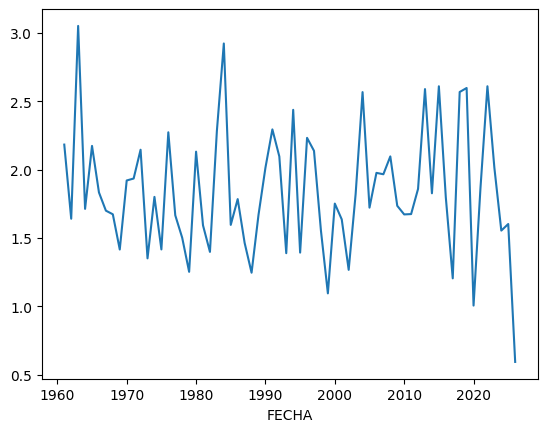

In [109]:
data['PRECIP'].groupby(data.index.year).mean().plot()

<Axes: xlabel='FECHA'>

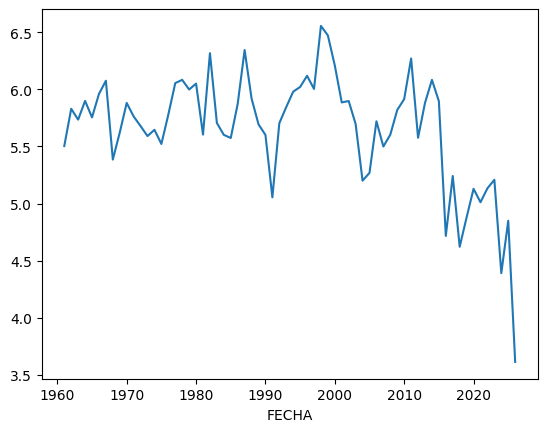

In [110]:
data['EVAP'].groupby(data.index.year).mean().plot()

<Axes: xlabel='FECHA'>

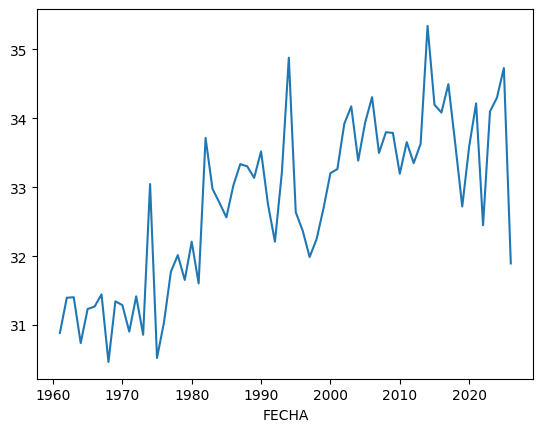

In [111]:
data['TMAX'].groupby(data.index.year).mean().plot()

<Axes: xlabel='FECHA'>

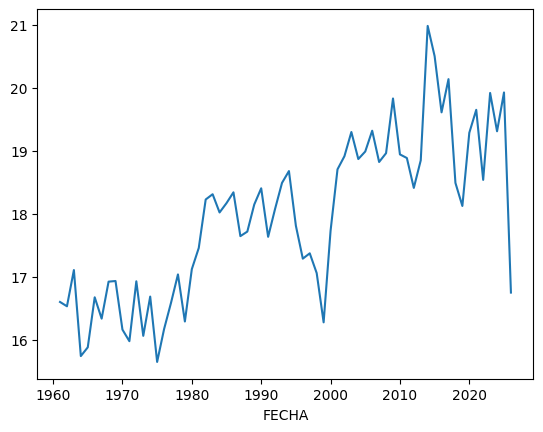

In [112]:
data['TMIN'].groupby(data.index.year).mean().plot()

Al observar las gráficas de líneas de los promedios anuales, podemos identificar patrones que las estadísticas simples no revelan a primera vista.

1. Tendencia de Temperaturas (TMAX y TMIN)
* Identificación: Ambas gráficas muestran un comportamiento estacionario con una ligera tendencia creciente a partir de la década de los 90.

* Análisis: Se observa que, aunque hay fluctuaciones naturales (años más calurosos que otros), los promedios anuales de la temperatura máxima se mantienen consistentemente por encima de los 30°C.

* Explicación: Esta estabilidad es típica de la región de Culiacán, Sinaloa. Sin embargo, los picos ascendentes en los años más recientes podrían estar relacionados con fenómenos climáticos globales como el calentamiento persistente o cambios en la urbanización alrededor de la estación.

2. Tendencia de Precipitación (PRECIP)
Identificación: Es una serie de tiempo con alta variabilidad y sin una tendencia clara de crecimiento o descenso.

* Análisis: La gráfica de lluvia es mucho más errática. Hay años con picos muy altos (años muy lluviosos) seguidos de valles profundos que representan periodos de sequía.

* Explicación: Esto refleja la naturaleza del ciclo hidrológico en el noroeste de México, el cual depende fuertemente de la temporada de huracanes y el fenómeno de "El Niño" o "La Niña". No existe una tendencia a que llueva más o menos cada año, sino que el comportamiento es cíclico e impredecible.

3. Tendencia de Evaporación (EVAP)
Identificación: Se observa una tendencia estacionaria y casi plana.

* Análisis: La línea se mantiene muy constante a través del tiempo.

* Explicación: Esto tiene sentido físico, ya que en una zona con temperaturas altas constantes como Culiacán, la capacidad de la atmósfera para evaporar agua se mantiene en niveles similares año con año, siempre que la humedad y el viento no varíen drásticamente.

#Comentarios y conclusiones

* Interpretación Global: Los datos revelan que la estación de Culiacán tiene un clima cálido-estable. Mientras que las temperaturas son predecibles y constantes (baja desviación estándar y tendencia lineal), la lluvia es el elemento de mayor incertidumbre (alta desviación estándar y tendencia errática).

* Relación Gráfico-Numérica: Las gráficas de líneas confirmaron lo que vimos en los histogramas: la temperatura se agrupa de forma normal, mientras que la lluvia es un evento de extremos.

* Implicaciones Prácticas: Este análisis es vital para la agricultura local. Saber que la tendencia de temperatura es estable pero la lluvia es altamente variable permite planear mejor los sistemas de riego y el almacenamiento en presas.

* Limitaciones y Mejoras: * Se detectaron valores que parecen ser promedios rellenados (como en la columna EVAP), lo que podría sesgar ligeramente los resultados.

* Como sugerencia de mejora, sería ideal cruzar estos datos con registros de fenómenos como "El Niño" para explicar los años con picos de lluvia atípicos.